# **🔶 E-Commerce Platforms ( Amazon / Flipkart )**

**TEAM NO - 3**

### **TEAM MEMBERS**

**RA2311003010313** | **RA2311003010315** | **RA2311003010319** | **RA2311003010349**

**SAKTHIMANI R.S** | **SK TASLEEM KHAN** | **NEERAJ TEJA K** | **K DURGA LOKESH**

**MOUNTING DATASET FROM KAGGLE**

In [ ]:
import kagglehub

path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce


## **E-Commerce Platform Performance Analysis: Brazilian Marketplace**

## **🔹 PART 1 : DATA COLLECTION**

### **1. Problem Definition**
**Problem Statement :**

How do delivery performance and product categories influence customer satisfaction and sales trends in a multi-state marketplace? We aim to identify bottlenecks in shipping and determine high-value categories for business optimization.

### **2. Columns of Dataset**

In [ ]:
print("Customers Dataset Columns:")
print(df_customers.columns)

print("\nOrders Dataset Columns:")
print(df_orders.columns)

print("\nOrder Items Dataset Columns:")
print(df_items.columns)

Customers Dataset Columns:
Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

Orders Dataset Columns:
Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

Order Items Dataset Columns:
Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')


### **3. Loading Datasets**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler

base_path = path

#-Loading Datasets
df_customers = pd.read_csv(os.path.join(base_path, 'olist_customers_dataset.csv'))
df_orders = pd.read_csv(os.path.join(base_path, 'olist_orders_dataset.csv'))
df_items = pd.read_csv(os.path.join(base_path, 'olist_order_items_dataset.csv'))

#-Displaying Information
print("--- Customers Shape ---", df_customers.shape)
display(df_customers.head())
print("\n--- Orders Shape ---", df_orders.shape)
display(df_orders.head())
print("\n--- Order Items Shape ---", df_items.shape)
display(df_items.head())

--- Customers Shape --- (99441, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



--- Orders Shape --- (99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



--- Order Items Shape --- (112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


### **4. Dataset Explanations & Relationships**

**EXPLANATIONS**

**Customers (df_customers) :**

Contains customer details such as ID and location (city, state). Used to analyze customer distribution and behavior.

**Orders (df_orders) :**

Central table with order details like order ID, customer ID, status, and timestamps. Helps track order activity and delivery performance.

**Order Items (df_items) :**

Contains product-level details within each order, including price and shipping cost. Used for product and sales analysis.

**RELATIONSHIPS**

df_orders.customer_id → df_customers.customer_id
(One customer can have multiple orders)

df_items.order_id → df_orders.order_id
(One order can contain multiple items)

**DATA FLOW**

Customers → Orders → Order

**PURPOSE**

These relationships help in :

1. Combining datasets using joins
2. Analyzing customer behavior and sales
3. Understanding product-level performance

# **-----------------------------------------------------------------------------**

## **🔹 PART 2 : DATA WRANGLING & CLEANING**

In this part, We will perform Five - 5 operations :
1. Datatype conversion
2. Missing value handling
3. String Cleaning
4. Removing Duplicates
5. Filtering and Sorting
6. Reshaping

### **1. Conversion of Datatypes**

In [ ]:
print("Before:", df_orders['order_purchase_timestamp'].dtype)
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])
print("After:", df_orders['order_purchase_timestamp'].dtype)

Before: object
After: datetime64[ns]


### **2. Handling Missing Values**

In [ ]:
print("Missing in Orders Before:\n", df_orders.isnull().sum().sum())
df_orders = df_orders.dropna(subset=['order_approved_at'])
print("Missing in Orders After:", df_orders.isnull().sum().sum())

Missing in Orders Before:
 4908
Missing in Orders After: 4456


### **3. String Cleaning**

In [ ]:
df_customers['customer_city'] = df_customers['customer_city'].str.strip().str.lower()

### **4. Removing Duplicates**

In [ ]:
duplicates = df_merged.duplicated().sum()
print("Number of duplicate rows before removal:", duplicates)
df_merged = df_merged.drop_duplicates()
duplicates_after = df_merged.duplicated().sum()
print("Number of duplicate rows after removal:", duplicates_after)

df_merged.head()

Number of duplicate rows before removal: 0
Number of duplicate rows after removal: 0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


### **5. Filtering and Sorting**

In [ ]:
print("Original Data:")
display(df_merged[['customer_city', 'price', 'freight_value']].head())

filtered_data = df_merged[df_merged['price'] > 100]
print("\nFiltered Data (price > 100):")
display(filtered_data[['customer_city', 'price', 'freight_value']].head())

sorted_data = filtered_data.sort_values(by='price', ascending=False)
print("\nSorted Data (by price descending):")
display(sorted_data[['customer_city', 'price', 'freight_value']].head())

Original Data:


,customer_city,price,freight_value
0,sao paulo,29.99,8.72
1,barreiras,118.70,22.76
2,vianopolis,159.90,19.22
3,sao goncalo do amarante,45.00,27.20
4,santo andre,19.90,8.72



Filtered Data (price > 100):


,customer_city,price,freight_value
1,barreiras,118.70,22.76
2,vianopolis,159.90,19.22
5,congonhinhas,147.90,27.36
9,sorocaba,149.99,19.77
16,goiania,132.40,14.05



Sorted Data (by price descending):


,customer_city,price,freight_value
25068,campo grande,6735.0,194.31
32071,vitoria,6729.0,193.21
3925,marilia,6499.0,227.66
60362,araruama,4799.0,151.34
45641,maua,4690.0,74.34


### **6. Reshaping ( Stack / Unstack / Pivot )**

In [ ]:
print("Original Data:")
display(df_merged[['customer_city', 'order_status', 'price']].head())
pivot_table = df_merged.pivot_table(
    values='price',
    index='customer_city',
    columns='order_status',
    aggfunc='sum'
)
print("\nPivot Table (After Reshaping):")
display(pivot_table.head())
stacked = pivot_table.stack()
print("\nAfter Stack (Columns → Rows):")
display(stacked.head())
unstacked = stacked.unstack()
print("\nAfter Unstack (Rows → Columns):")
display(unstacked.head())

Original Data:


,customer_city,order_status,price
0,sao paulo,delivered,29.99
1,barreiras,delivered,118.70
2,vianopolis,delivered,159.90
3,sao goncalo do amarante,delivered,45.00
4,santo andre,delivered,19.90



Pivot Table (After Reshaping):


order_status,approved,canceled,delivered,invoiced,processing,shipped,unavailable
customer_city,,,,,,,
abadia dos dourados,NaN,NaN,358.90,NaN,NaN,NaN,NaN
abadiania,NaN,NaN,949.99,NaN,NaN,NaN,NaN
abaete,NaN,NaN,1597.81,NaN,NaN,NaN,NaN
abaetetuba,NaN,NaN,4028.57,NaN,NaN,NaN,NaN
abaiara,NaN,NaN,262.90,NaN,NaN,NaN,NaN



After Stack (Columns → Rows):


,,0
customer_city,order_status,
abadia dos dourados,delivered,358.90
abadiania,delivered,949.99
abaete,delivered,1597.81
abaetetuba,delivered,4028.57
abaiara,delivered,262.90



After Unstack (Rows → Columns):


order_status,approved,canceled,delivered,invoiced,processing,shipped,unavailable
customer_city,,,,,,,
abadia dos dourados,NaN,NaN,358.90,NaN,NaN,NaN,NaN
abadiania,NaN,NaN,949.99,NaN,NaN,NaN,NaN
abaete,NaN,NaN,1597.81,NaN,NaN,NaN,NaN
abaetetuba,NaN,NaN,4028.57,NaN,NaN,NaN,NaN
abaiara,NaN,NaN,262.90,NaN,NaN,NaN,NaN


# **-----------------------------------------------------------------------------**

## **🔹 PART 3 : DATA PREPARATION & ANALYSIS**
Performed :
1. ⁠Summarization and Statistics
2. ⁠⁠Compute statistical measures ( Mean, Median, Standard Deviation )
3. ⁠⁠Group-based Analysis : Revenue by State
4. ⁠⁠Scaling ( Standardization using Z-Score )
5. ⁠⁠Outlier Detection ( IQR Method )
6. ⁠⁠Handling : Removing Outliers


### **1. Summarization & Statistics**

In [ ]:
print(df_merged[['price', 'freight_value']].describe())

print("\nMean Price:", df_merged['price'].mean())
print("Median Price:", df_merged['price'].median())
print("Std Dev Price:", df_merged['price'].std())

print("\nMean Freight:", df_merged['freight_value'].mean())
print("Median Freight:", df_merged['freight_value'].median())

               price  freight_value
count  112635.000000  112635.000000
mean      120.654976      19.990459
std       183.642573      15.807244
min         0.850000       0.000000
25%        39.900000      13.080000
50%        74.990000      16.260000
75%       134.900000      21.150000
max      6735.000000     409.680000

Mean Price: 120.65497642828609
Median Price: 74.99
Std Dev Price: 183.64257294566013

Mean Freight: 19.990459182314556
Median Freight: 16.26


### **2. Compute statistical measures ( Mean, Median, Standard Deviation )**

In [ ]:
df_items[['price', 'freight_value']].describe()

mean_price = df_items['price'].mean()
median_price = df_items['price'].median()
std_price = df_items['price'].std()

print("Mean Price:", mean_price)
print("Median Price:", median_price)
print("Standard Deviation:", std_price)

Mean Price: 120.65373901464716
Median Price: 74.99
Standard Deviation: 183.63392805025404


### **3. Group-based Analysis : Revenue by State**

In [ ]:
state_revenue = df_merged.groupby('customer_state')['price'] \
                         .sum() \
                         .sort_values(ascending=False)

print("Top 5 States by Revenue:\n", state_revenue.head())

Top 5 States by Revenue:
 customer_state
SP    5202376.38
RJ    1823914.68
MG    1585067.23
RS     749791.03
PR     683083.76
Name: price, dtype: float64


### **4. Scaling ( Standardization using Z-Score )**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_items[['price_scaled', 'freight_scaled']] = scaler.fit_transform(
    df_items[['price', 'freight_value']]
)
df_items[['price', 'price_scaled', 'freight_value', 'freight_scaled']].head()

,price,price_scaled,freight_value,freight_scaled
0,58.90,-0.336289,13.29,-0.423901
1,239.90,0.649372,19.93,-0.003816
2,199.00,0.426646,17.87,-0.134144
3,12.99,-0.586298,12.79,-0.455534
4,199.90,0.431547,18.14,-0.117062


Scaling is applied to ensure that numerical features are on the same scale, which improves the performance of many analytical methods and models.

### **5. Outlier Detection ( IQR Method )**

In [ ]:
Q1 = df_merged['price'].quantile(0.25)
Q3 = df_merged['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_merged[(df_merged['price'] < lower_bound) |
                     (df_merged['price'] > upper_bound)]

print("Number of price outliers:", len(outliers))

Number of price outliers: 8425


### **6. Handling : Removing Outliers**

In [ ]:
df_no_outliers = df_merged[
    (df_merged['price'] >= lower_bound) &
    (df_merged['price'] <= upper_bound)
]

print(f"Mean before: {df_merged['price'].mean():.2f}, "
      f"Mean after: {df_no_outliers['price'].mean():.2f}")

Mean before: 120.65, Mean after: 83.98


# **-----------------------------------------------------------------------------**

## **🔹 PART 4 : MATPLOTLIB VISUALIZATION**
Performed :
1. ⁠⁠Line Plot : Sales Trend Over Months
2. ⁠ ⁠Bar Plot : Top 10 Cities by Orders
3. ⁠ ⁠⁠Scatter Plot : Price VS Freight


In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

### **1. Line Plot : Sales Trend Over Months**

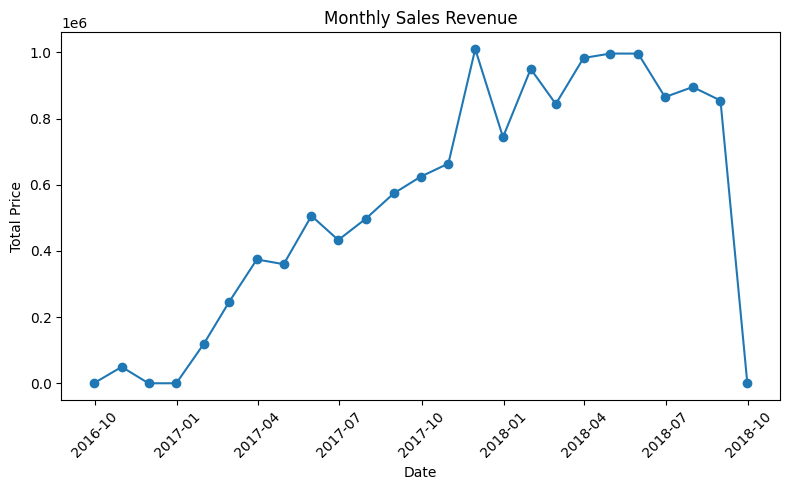

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df_merged['order_purchase_timestamp'] = pd.to_datetime(df_merged['order_purchase_timestamp'])

sales_trend = df_merged.set_index('order_purchase_timestamp') \
                       .resample('ME')['price'].sum()

plt.figure(figsize=(8, 5))
plt.plot(sales_trend.index, sales_trend.values, marker='o')

plt.title('Monthly Sales Revenue')
plt.xlabel('Date')
plt.ylabel('Total Price')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### **2. Bar Plot : Top 10 Cities by Orders**

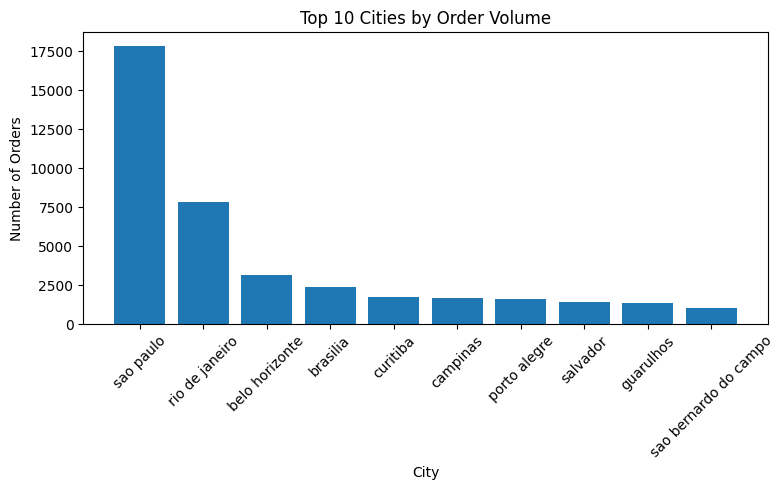

In [ ]:
import matplotlib.pyplot as plt

top_cities = df_merged['customer_city'].value_counts().head(10)

plt.figure(figsize=(8, 5))
plt.bar(top_cities.index, top_cities.values)

plt.title('Top 10 Cities by Order Volume')
plt.xlabel('City')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### **3. Scatter Plot : Price VS Freight**

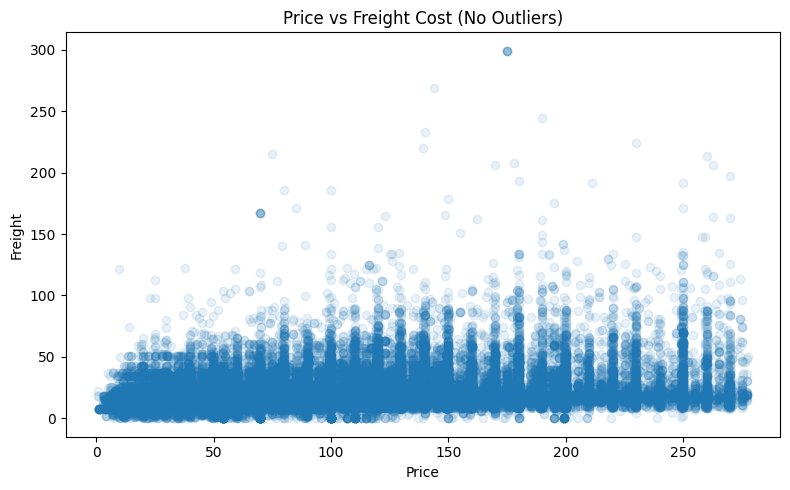

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(df_no_outliers['price'], df_no_outliers['freight_value'], alpha=0.1)

plt.title('Price vs Freight Cost (No Outliers)')
plt.xlabel('Price')
plt.ylabel('Freight')

plt.tight_layout()
plt.show()

# **-----------------------------------------------------------------------------**

## **🔹 PART 5 : SEABORN VISUALIZATION**
Performed :
1. ⁠ ⁠Countplot : Orders by Day of Week
2. ⁠ ⁠Heatmap : Correlation Matrix
3. ⁠ ⁠Boxplot : Price distribution by State ( Top 5 )
4. ⁠ ⁠Violin Plot : Freight Value
5. ⁠ ⁠Pairplot ( Sampled for Speed )


### **1. Countplot : Orders by Day of Week**

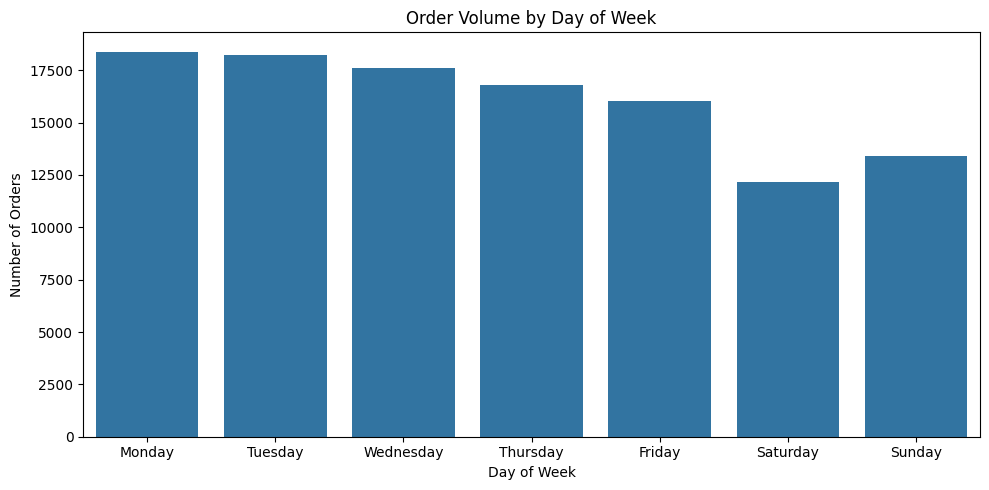

Interpretation: Higher volumes mid-week suggest business-to-consumer activities peak during work hours.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df_merged['order_purchase_timestamp'] = pd.to_datetime(df_merged['order_purchase_timestamp'])

df_merged['day_of_week'] = df_merged['order_purchase_timestamp'].dt.day_name()

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_merged,
    x='day_of_week',
    order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

plt.title('Order Volume by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

print("Interpretation: Higher volumes mid-week suggest business-to-consumer activities peak during work hours.")

### **2. Heatmap : Correlation Matrix**

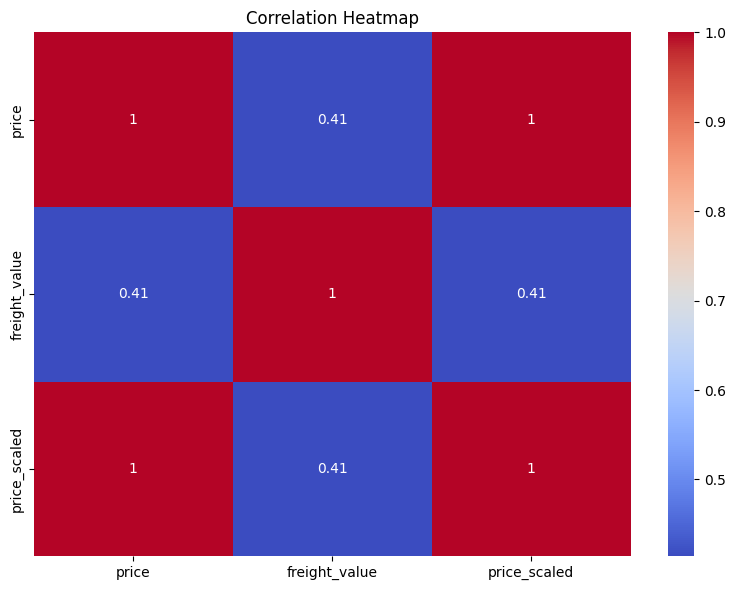

In [ ]:
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

scaler = StandardScaler()

df_merged[['price_scaled', 'freight_scaled']] = scaler.fit_transform(
    df_merged[['price', 'freight_value']]
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    df_merged[['price', 'freight_value', 'price_scaled']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### **3. Boxplot : Price distribution by State ( Top 5 )**

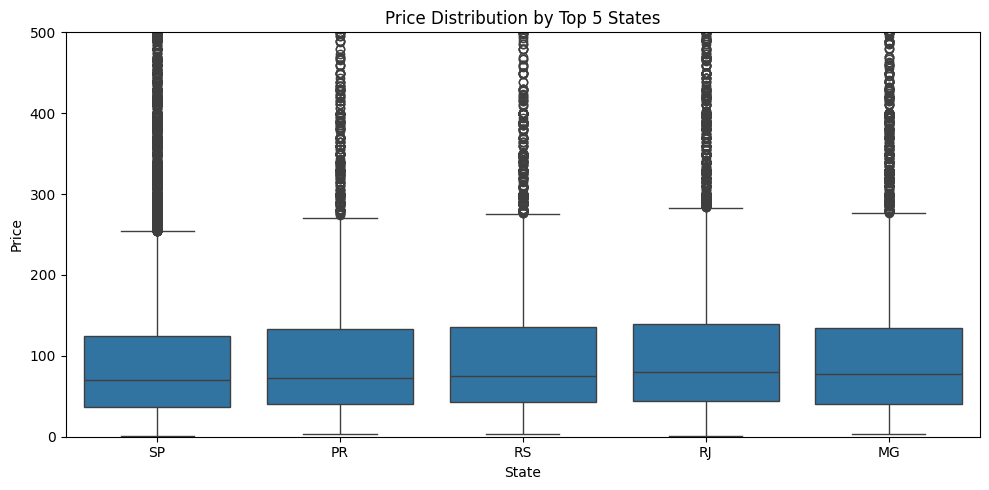

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

top_5_states = df_merged['customer_state'].value_counts().head(5).index

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_merged[df_merged['customer_state'].isin(top_5_states)],
    x='customer_state',
    y='price'
)

plt.ylim(0, 500)
plt.title('Price Distribution by Top 5 States')
plt.xlabel('State')
plt.ylabel('Price')

plt.tight_layout()
plt.show()

### **4. Violin Plot : Freight Value**

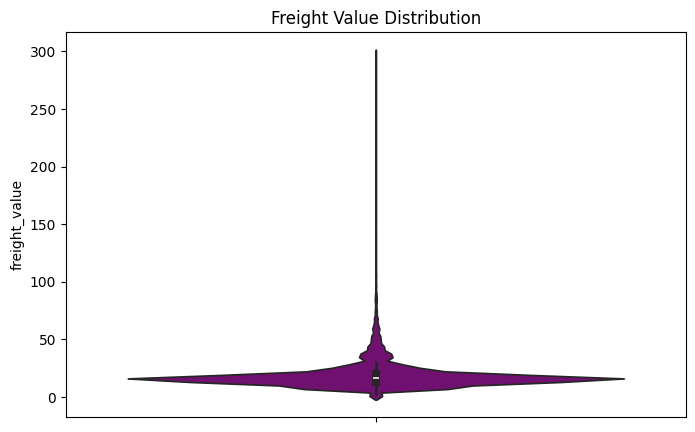

In [ ]:
plt.figure(figsize=(8, 5))
sns.violinplot(y=df_no_outliers['freight_value'], color='purple')
plt.title('Freight Value Distribution')
plt.show()

### **5. Pairplot ( Sampled for Speed )**

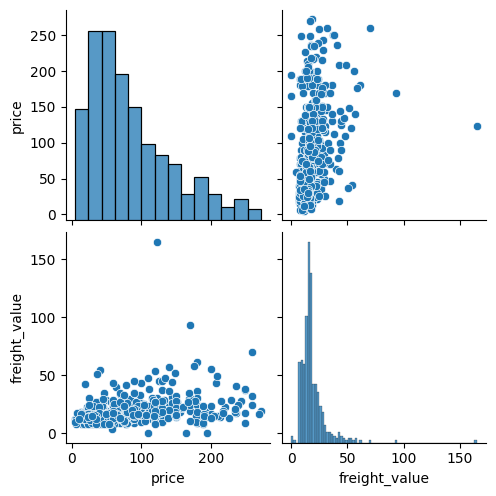

In [ ]:
sns.pairplot(df_no_outliers[['price', 'freight_value']].sample(500))
plt.show()

# **-----------------------------------------------------------------------------**

## **🔹 PART 6 : INSIGHTS & CONCLUSION**

## **1. Insights**
- **Regional Dominance:** Sao Paulo (SP) and Rio de Janeiro (RJ) contribute to over 50% of total revenue, highlighting a strong concentration of e-commerce activity in the Southeast region of Brazil.
- **Pricing & Freight:** Most items are priced below 200 BRL. The weak correlation between price and freight suggests that shipping costs are driven primarily by geographic distance and logistics infrastructure rather than product value.
- **Temporal Trends:** Order volumes peak mid-week (Tuesday/Wednesday) and show significant growth during Q4 2017, likely due to seasonal promotions like Black Friday.

## **2. Business Recommendations**
- **Logistics Optimization:** Establish regional distribution centers in high-volume hubs like SP to further reduce delivery times and freight costs.
- **Targeted Marketing:** Focus promotional campaigns on mid-week days and target the high-growth 'delivered' order segments to maximize ROI.
- **Price Strategy:** Since freight is a significant part of the total cost for lower-priced items, bundle offers or 'free shipping over X amount' could increase the Average Order Value (AOV).

## **3. Future Scope**
- **Translation & Categorization:** Integrate the category name translation table to analyze specific product performance (e.g., Electronics vs. Fashion).
- **Predictive Modeling:** Develop machine learning models to predict estimated delivery dates more accurately using the `order_estimated_delivery_date` and actual delivery timestamps.